Cell 1: Imports
Cell 2: Load CSV + shape + data types + missing values
Cell 3: Loan_Status Y/N countplot
Cell 4: Numeric boxplots against Loan_Status
Cell 5: Categorical countplots against Loan_Status
Cell 6: Correlation heatmap
Cell 7: Approval rate by Credit_History
Cell 8: Approval rates by categorical columns

Cell 1 – Imports

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

Cell 2 – Load and basic profile

In [11]:
data_path = Path("../data/raw.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values (count):\n", df.isna().sum())
print("\nMissing values (%):\n", (df.isna().mean() * 100).sort_values(ascending=False).head(15))
print("\nDescribe (numeric):\n", df.describe().T)
print("\nDescribe (categorical):\n", df.describe(include=["object", "category"]).T)

Shape: (381, 13)

Columns:
 ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Dtypes:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing values (count):
 Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

Missing values (%)

Cell 3 – Inspect target (Loan_Status)

Target value counts:
Loan_Status
Y    271
N    110
Name: count, dtype: int64

Target proportions:
Loan_Status
Y    0.711286
N    0.288714
Name: proportion, dtype: float64


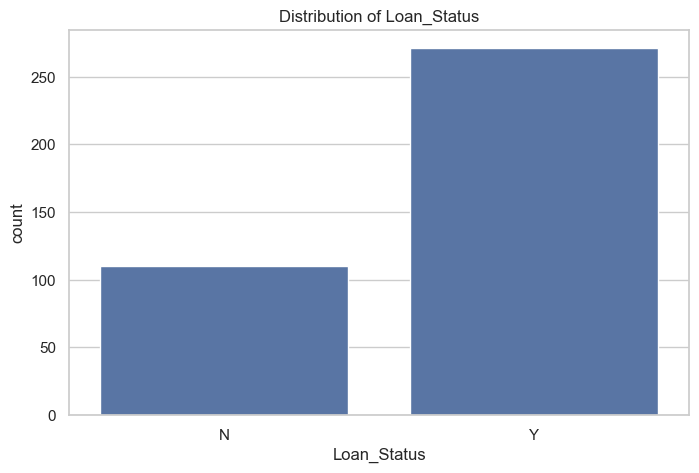

In [12]:
target_col = "Loan_Status"

if target_col not in df.columns:
    # Try case-insensitive search
    candidates = [c for c in df.columns if "loan" in c.lower() and "status" in c.lower()]
    raise ValueError(f"Target column '{target_col}' not found. Closest matches: {candidates}")

print("Target value counts:")
print(df[target_col].value_counts(dropna=False))

print("\nTarget proportions:")
print(df[target_col].value_counts(normalize=True, dropna=False))

sns.countplot(data=df, x=target_col)
plt.title(f"Distribution of {target_col}");

Cell 4 – Numeric features vs target

Numeric columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


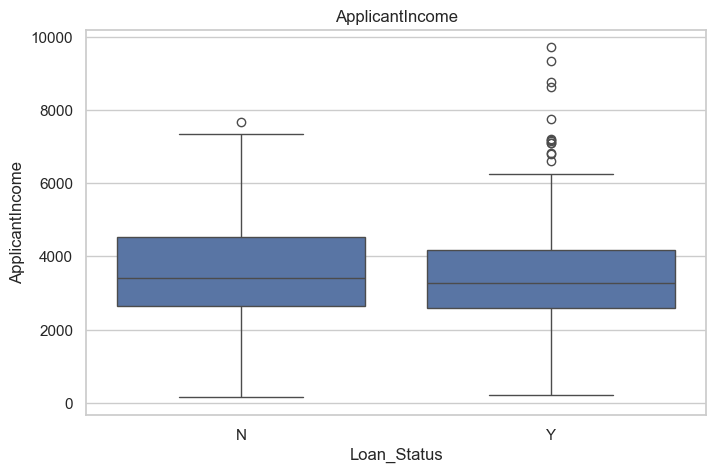

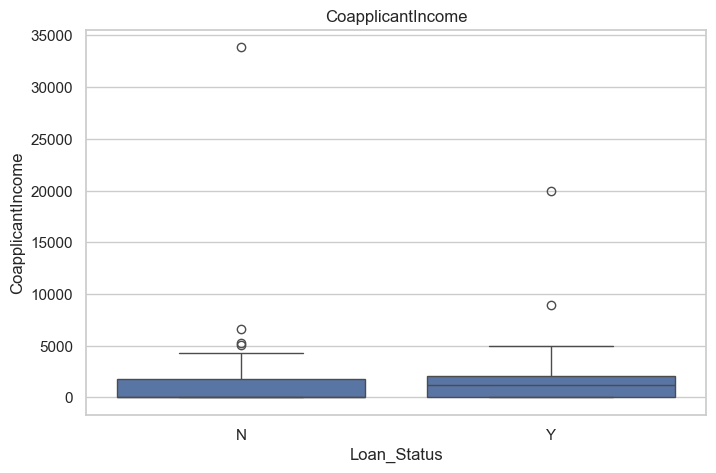

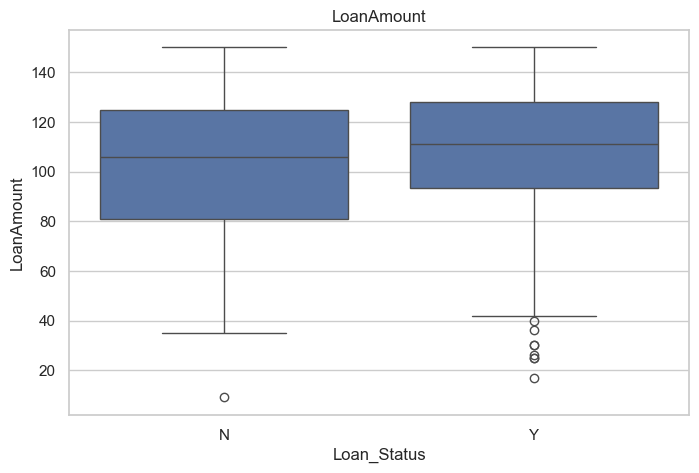

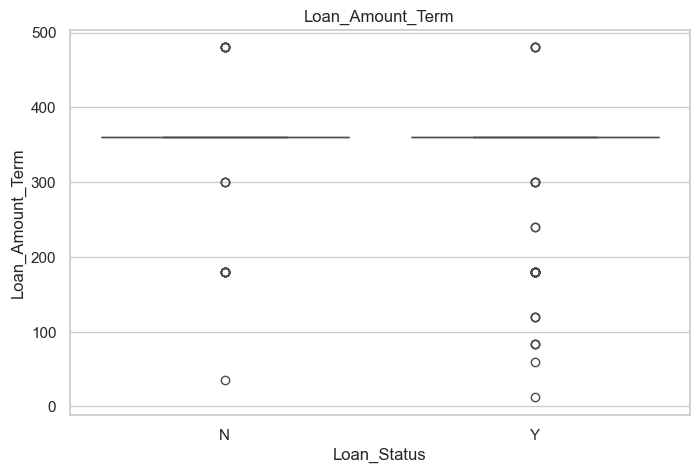

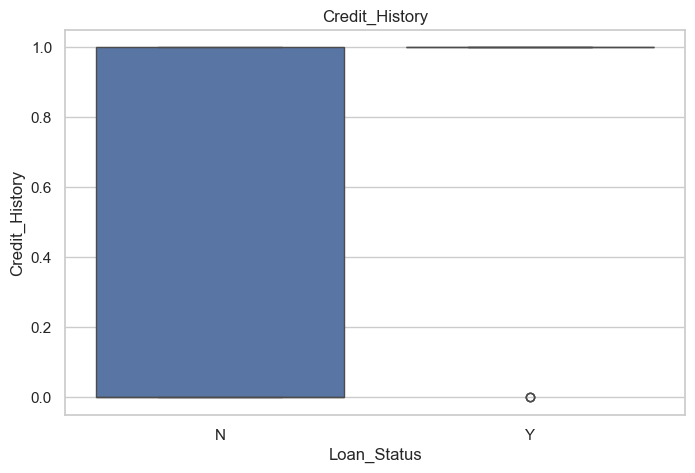

In [13]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

print("Numeric columns:", num_cols)

for col in num_cols:
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(col)
    plt.show()

Cell 5 – Categorical features vs target

Categorical columns (excluding Loan_ID): ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


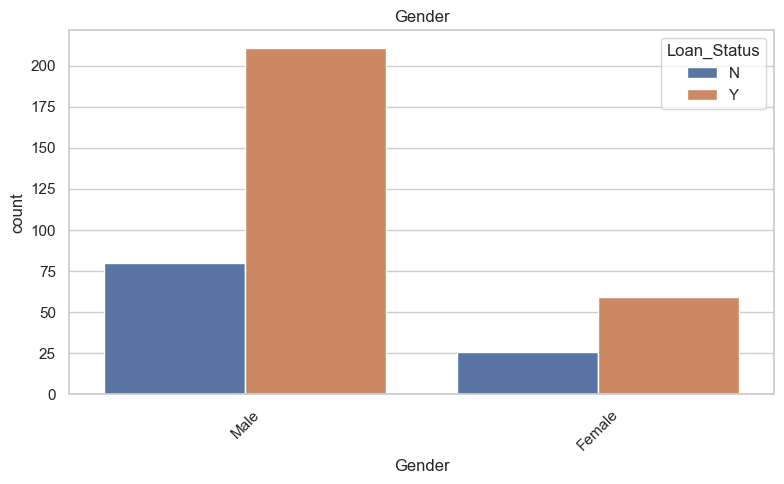

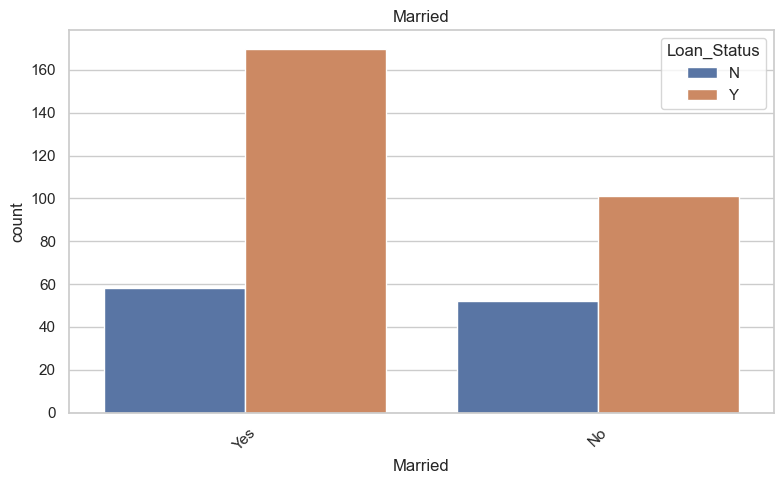

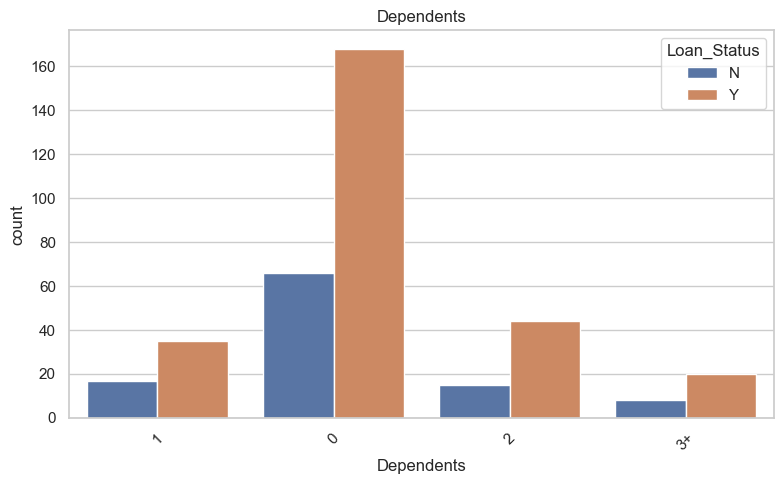

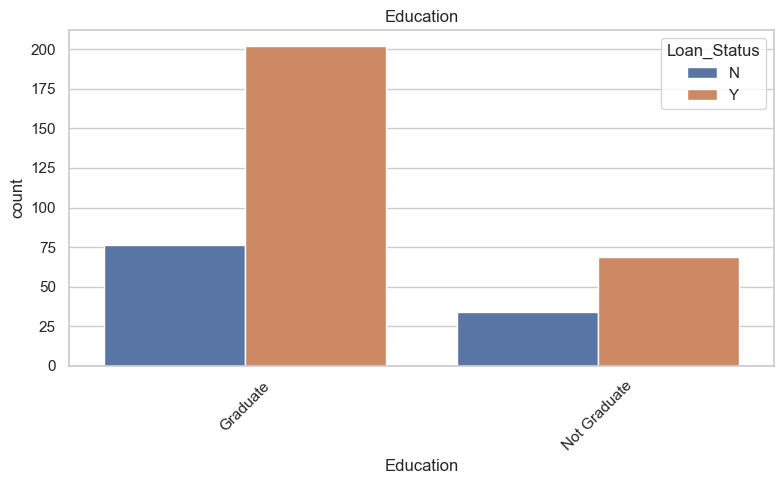

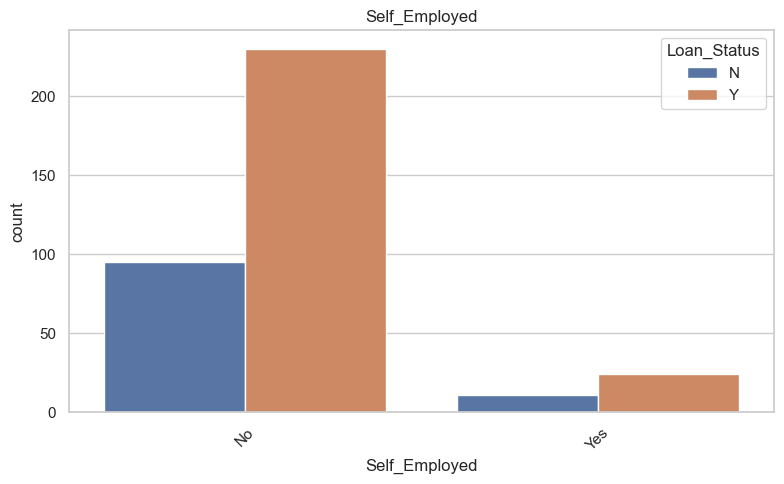

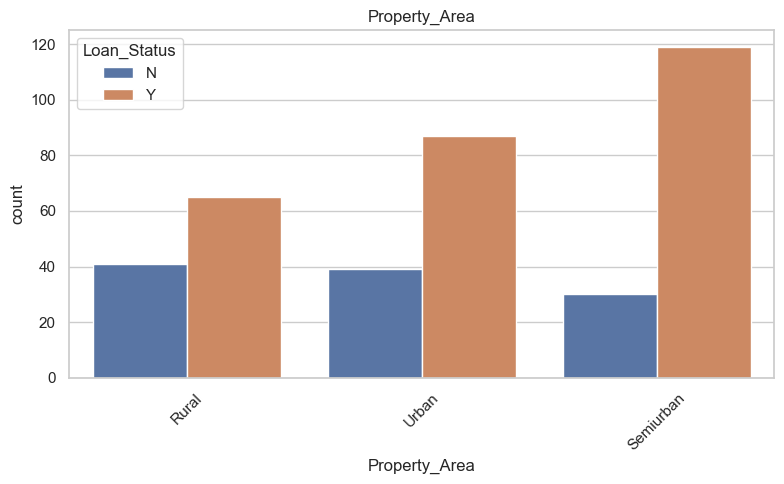

In [14]:
cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col and c != "Loan_ID"]

print("Categorical columns (excluding Loan_ID):", cat_cols)

for col in cat_cols:
    sns.countplot(data=df, x=col, hue=target_col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Cell 6 – Correlation heatmap (numeric only)

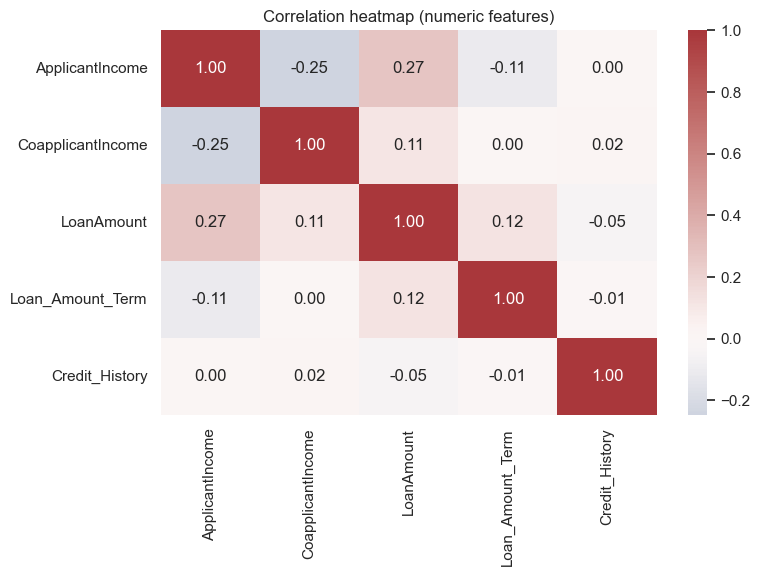

In [15]:
num_df = df[num_cols]
corr = num_df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlation heatmap (numeric features)")
plt.show()

Cell 7: Approval rate by Credit_History

Credit_History
0.0    0.052632
1.0    0.823129
Name: Loan_Status, dtype: float64


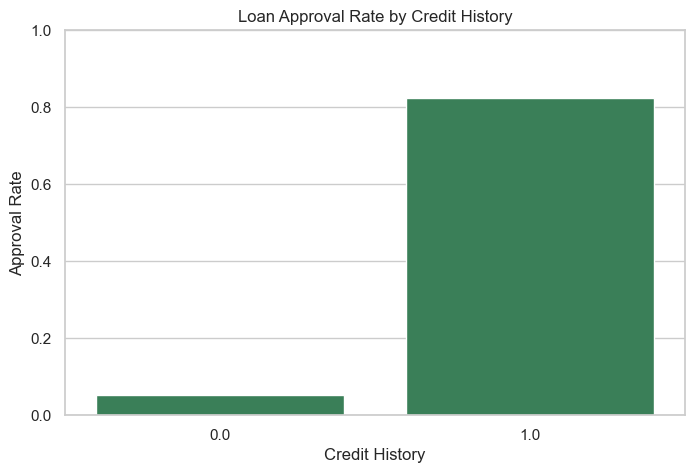

In [17]:
# Approval rate based on credit history

credit_approval_rate = (
    df.groupby("Credit_History")["Loan_Status"]
    .apply(lambda x: (x == "Y").mean())
)

print(credit_approval_rate)

sns.barplot(
    x=credit_approval_rate.index.astype(str),
    y=credit_approval_rate.values,
    color="seagreen"
)

plt.title("Loan Approval Rate by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.show()

Cell 8: Approval rates by categorical columns



Approval rate by Gender:
Gender
Male      0.725086
Female    0.694118
Name: Loan_Status, dtype: float64


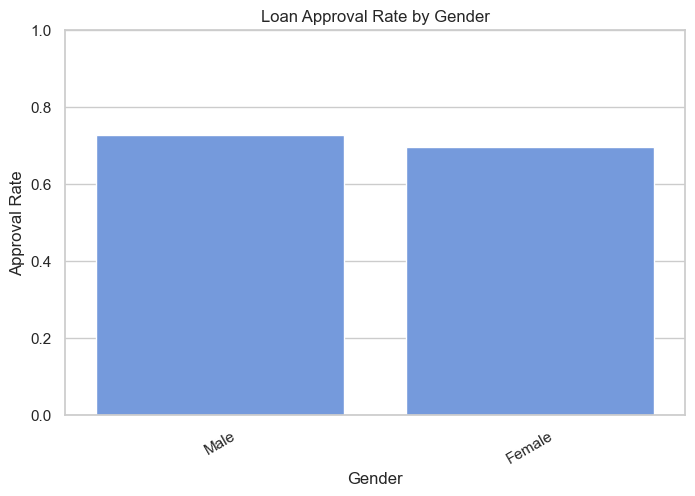


Approval rate by Married:
Married
Yes    0.745614
No     0.660131
Name: Loan_Status, dtype: float64


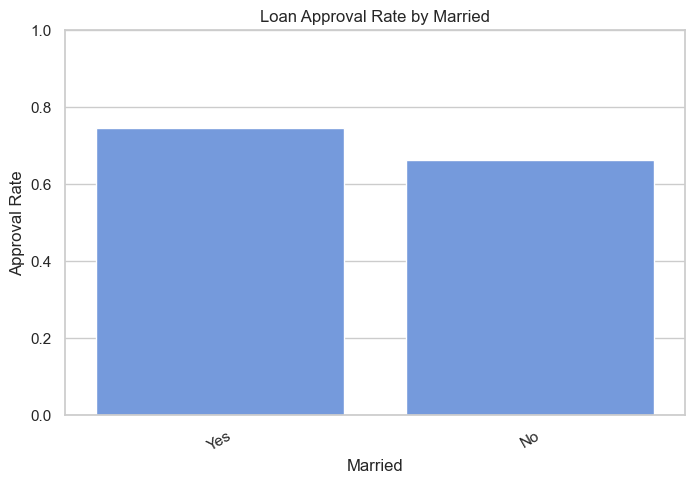


Approval rate by Dependents:
Dependents
2     0.745763
0     0.717949
3+    0.714286
1     0.673077
Name: Loan_Status, dtype: float64


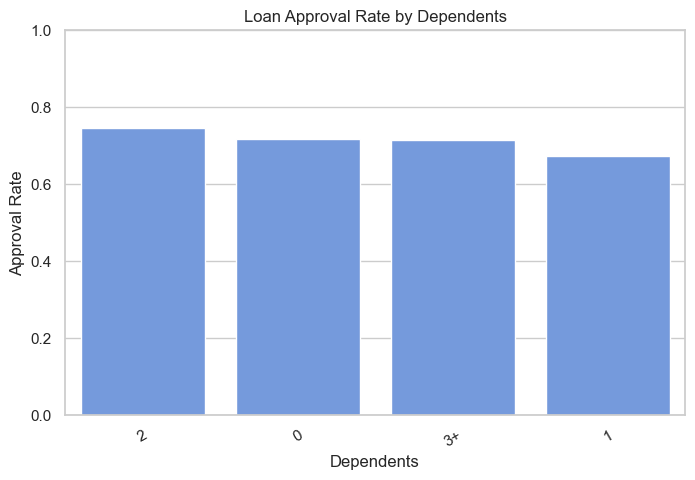


Approval rate by Education:
Education
Graduate        0.726619
Not Graduate    0.669903
Name: Loan_Status, dtype: float64


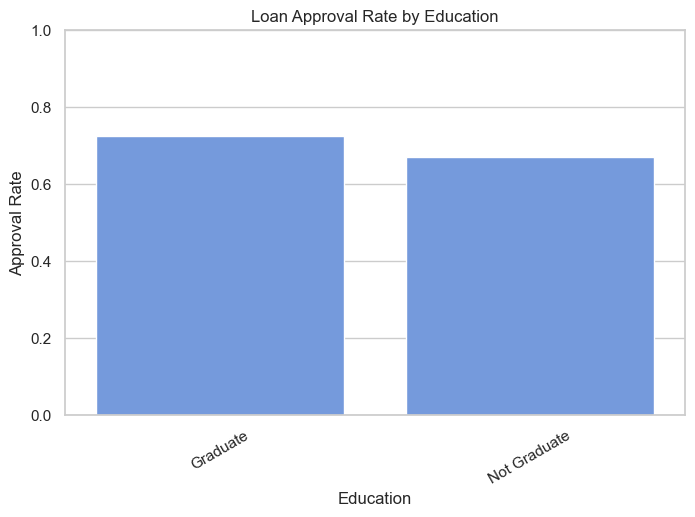


Approval rate by Self_Employed:
Self_Employed
No     0.707692
Yes    0.685714
Name: Loan_Status, dtype: float64


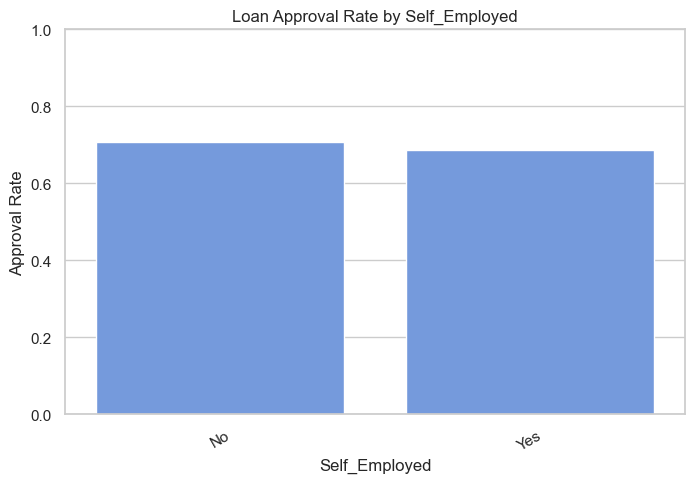


Approval rate by Property_Area:
Property_Area
Semiurban    0.798658
Urban        0.690476
Rural        0.613208
Name: Loan_Status, dtype: float64


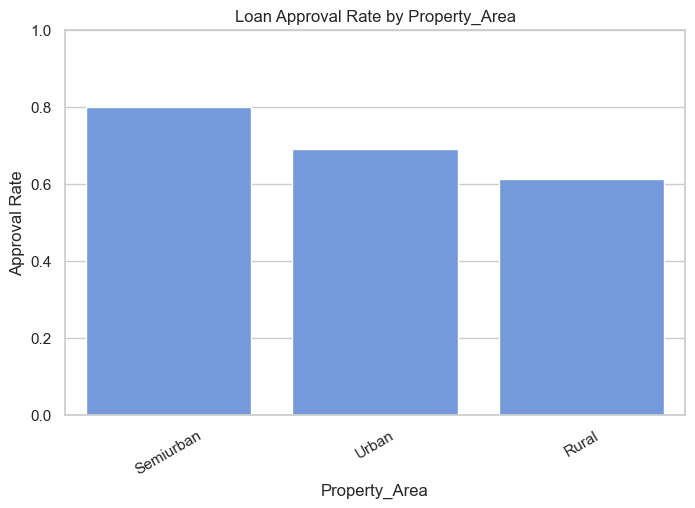

In [18]:
# Approval rate for each categorical feature

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

for col in categorical_columns:
    if col in df.columns:

        approval_rates = (
            df.groupby(col)["Loan_Status"]
            .apply(lambda x: (x == "Y").mean())
            .sort_values(ascending=False)
        )

        print(f"\nApproval rate by {col}:")
        print(approval_rates)

        sns.barplot(
            x=approval_rates.index.astype(str),
            y=approval_rates.values,
            color="cornflowerblue"
        )

        plt.title(f"Loan Approval Rate by {col}")
        plt.xlabel(col)
        plt.ylabel("Approval Rate")
        plt.ylim(0, 1)
        plt.xticks(rotation=30)
        plt.show()

## Phase 2: Data Understanding – Key Findings

- The dataset contains loan applicant details and the target column `Loan_Status`.
- `Loan_Status` has two classes: Y (approved) and N (rejected).
- Some columns contain missing values, such as Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History.
- Credit history appears to have a strong relationship with loan approval.
- Income and loan amount may contain outliers because some applicants have unusually high values.
- Categorical features such as Property_Area, Education, and Married may also influence approval.
- The next phase is Data Preparation, where missing values will be handled and categorical values will be converted into machine-readable numbers.